# Heston Calibration

Can we recover Heston parameters from option prices? We generate synthetic market data from known parameters, calibrate back, and see what breaks.

SLSQP with a single starting point gets kappa wrong by 35% — the loss surface is flat in that direction. Levenberg-Marquardt does better, and the Hessian eigenspectrum shows exactly why.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from scipy.optimize import minimize, least_squares, differential_evolution
import warnings
import time

import sys
sys.path.insert(0, '..')
from utils import Heston_CF, Heston_price, bs_call_price, bs_vega, implied_vol

sys.path.insert(0, '../greeks')
from cos_greeks import cos_price

## COS Pricing

COS {cite:p}`FangOosterlee2008` encodes the payoff directly in Fourier-cosine coefficients — no numerical integration, exponential convergence. Implementation in `greeks/cos_greeks.py`.

In [2]:
def Heston_price_COS(S0, K, T, r, kappa, nu0, theta, xi, rho, N=128):
    """Heston call price via COS method. """
    # CF of log-returns: phi(u) for ln(S_T/S_0)
    # Heston_CF gives E[exp(iu*ln(S_T))], so divide by S0^{iu}
    def cf(u):
        return Heston_CF(u, S0, T, r, kappa, nu0, theta, xi, rho) / S0**(1j*u)

    # time-averaged variance for domain truncation
    # E[∫v_s ds] / T ≈ (ν₀ - θ)(1 - e^{-κT})/(κT) + θ
    if abs(kappa * T) > 1e-8:
        avg_var = (nu0 - theta) / (kappa * T) * (1 - np.exp(-kappa * T)) + theta
    else:
        avg_var = nu0  # small T limit
    std = np.sqrt(max(avg_var, 1e-6))

    return cos_price(S0, K, T, r, cf, N=N, L=10, opt_type='call', std=std)

## Sanity check: COS convergence

Gil-Pelaez with n=200 is itself approximate. We use a high-resolution reference (n=10000) and check both methods against it.

In [3]:
def Heston_price_hires(S0, K, T, r, kappa, nu0, theta, xi, rho, n=10000, umax=200):
    """Gil-Pelaez with high resolution for reference prices."""
    params = (S0, T, r, kappa, nu0, theta, xi, rho)
    P1, P2 = 0.5, 0.5
    du = umax / n
    u = du / 2
    for i in range(n):
        temp1 = (np.exp(-1j * u * np.log(K)) * Heston_CF(u - 1j, *params)
                 / (1j * u * Heston_CF(-1j, *params)))
        temp2 = np.exp(-1j * u * np.log(K)) * Heston_CF(u, *params) / (1j * u)
        P1 += 1 / np.pi * temp1 * du
        P2 += 1 / np.pi * temp2 * du
        u += du
    return np.real(S0 * P1 - K * np.exp(-r * T) * P2)

# test params
S0 = 100
r = 0.05
kappa, nu0, theta, xi, rho = 0.8, 0.3**2, 0.3**2, 0.5, -0.8

test_cases = [
    (80, 0.25),
    (100, 0.5),
    (120, 1.0),
    (90, 0.25),
    (110, 0.5),
]

print(f"{'K':>6} {'T':>6} {'Reference':>12} {'COS(128)':>12} {'GP(200)':>12} {'COS err':>10} {'GP err':>10}")
print("-" * 75)

for K, T in test_cases:
    price_ref = Heston_price_hires(S0, K, T, r, kappa, nu0, theta, xi, rho)
    price_cos = Heston_price_COS(S0, K, T, r, kappa, nu0, theta, xi, rho)
    price_gp = Heston_price(S0, K, T, r, kappa, nu0, theta, xi, rho)
    err_cos = abs(price_cos - price_ref)
    err_gp = abs(price_gp - price_ref)
    print(f"{K:>6.0f} {T:>6.2f} {price_ref:>12.6f} {price_cos:>12.6f} {price_gp:>12.6f} {err_cos:>10.2e} {err_gp:>10.2e}")

     K      T    Reference     COS(128)      GP(200)    COS err     GP err
---------------------------------------------------------------------------
    80   0.25    21.673670    21.673670    21.672486   4.26e-10   1.18e-03
   100   0.50     9.323819     9.323819     9.324225   3.78e-08   4.06e-04
   120   1.00     4.396658     4.396657     4.396639   2.85e-07   1.85e-05
    90   0.25    13.211971    13.211971    13.210964   5.23e-10   1.01e-03
   110   0.50     4.452662     4.452662     4.452337   2.00e-08   3.26e-04


## Synthetic market data

We know the true parameters, so we can measure how badly calibration recovers them. Using COS for both data generation and calibration — otherwise method mismatch contaminates the experiment.

In [4]:
# "true" Heston parameters (what we want to recover)
r = 0.05
S0 = 100
true_kappa = 1.5
true_nu0 = 0.04      # vol = 20%
true_theta = 0.06    # vol = 24.5%
true_xi = 0.4
true_rho = -0.7
true_params = [true_kappa, true_nu0, true_theta, true_xi, true_rho]

# wider strike range: ±20% moneyness gives the optimizer skew + curvature info
K_strikes = [80, 85, 90, 95, 100, 105, 110, 115, 120]
T_maturities = [0.25, 0.5, 1.0]

K_mkt = K_strikes * len(T_maturities)
T_mkt = sum([[T]*len(K_strikes) for T in T_maturities], [])
n_instruments = len(K_mkt)

# generate with COS — same method we'll calibrate with
Price_mkt = [Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *true_params) for i in range(n_instruments)]
IV_mkt = [implied_vol(Price_mkt[i], S0, K_mkt[i], r, T_mkt[i]) for i in range(n_instruments)]

print(f"True params: kappa={true_kappa}, nu0={true_nu0:.4f}, theta={true_theta:.4f}, xi={true_xi}, rho={true_rho}")
print(f"Feller check: 2*kappa*theta - xi^2 = {2*true_kappa*true_theta - true_xi**2:.4f} > 0")
print(f"{n_instruments} instruments across {len(T_maturities)} maturities, strikes {K_strikes[0]}-{K_strikes[-1]}\n")

print(f"{'K':>8} {'T':>6} {'IV':>8} {'Price':>10}")
for i in range(n_instruments):
    print(f"{K_mkt[i]:>8.1f} {T_mkt[i]:>6.2f} {IV_mkt[i]:>8.1%} {Price_mkt[i]:>10.4f}")

True params: kappa=1.5, nu0=0.0400, theta=0.0600, xi=0.4, rho=-0.7
Feller check: 2*kappa*theta - xi^2 = 0.0200 > 0
27 instruments across 3 maturities, strikes 80-120

       K      T       IV      Price
    80.0   0.25    26.3%    21.1631
    85.0   0.25    24.9%    16.4659
    90.0   0.25    23.4%    12.0261
    95.0   0.25    22.0%     8.0282
   100.0   0.25    20.5%     4.7065
   105.0   0.25    19.0%     2.2859
   110.0   0.25    17.6%     0.8577
   115.0   0.25    16.6%     0.2398
   120.0   0.25    16.0%     0.0524
    80.0   0.50    26.0%    22.6400
    85.0   0.50    24.7%    18.2513
    90.0   0.50    23.5%    14.1344
    95.0   0.50    22.2%    10.3915
   100.0   0.50    20.9%     7.1382
   105.0   0.50    19.7%     4.4886
   110.0   0.50    18.5%     2.5250
   115.0   0.50    17.5%     1.2485
   120.0   0.50    16.7%     0.5434
    80.0   1.00    25.7%    25.5434
    85.0   1.00    24.6%    21.5169
    90.0   1.00    23.6%    17.7304
    95.0   1.00    22.6%    14.2345
   10

## Calibration setup

Two objectives: MSE on prices vs MSE on implied vols. Feller constraint $2\kappa\theta > \xi^2$ enforced via both inequality constraints and explicit parameter bounds.

In [5]:
# params = [kappa, nu0, theta, xi, rho]
param_names = ['kappa', 'nu0', 'theta', 'xi', 'rho']

def MSE_Price_COS(params):
    """MSE between market and model prices using COS."""
    mse = 0
    for i in range(n_instruments):
        model_price = Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *params)
        mse += (model_price - Price_mkt[i])**2
    return mse / n_instruments

def MSE_IV_COS(params):
    """MSE between market and model implied vols using COS."""
    mse = 0
    for i in range(n_instruments):
        model_price = Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *params)
        model_iv = implied_vol(model_price, S0, K_mkt[i], r, T_mkt[i])
        mse += (model_iv - IV_mkt[i])**2
    return mse / n_instruments

def residuals_price_COS(params):
    """Residual vector for least_squares (price differences)."""
    res = np.zeros(n_instruments)
    for i in range(n_instruments):
        res[i] = Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *params) - Price_mkt[i]
    return res

def residuals_iv_COS(params):
    """Residual vector for least_squares (IV differences)."""
    res = np.zeros(n_instruments)
    for i in range(n_instruments):
        model_price = Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *params)
        res[i] = implied_vol(model_price, S0, K_mkt[i], r, T_mkt[i]) - IV_mkt[i]
    return res

# explicit bounds: [kappa, nu0, theta, xi, rho]
bounds_lower = [0.01, 1e-4, 1e-4, 0.01, -0.999]
bounds_upper = [20.0, 1.0, 1.0, 3.0, 0.999]

# SLSQP constraints (redundant with bounds, but SLSQP uses these)
cons = (
    {'type': 'ineq', 'fun': lambda x: x[0] - bounds_lower[0]},
    {'type': 'ineq', 'fun': lambda x: bounds_upper[0] - x[0]},
    {'type': 'ineq', 'fun': lambda x: x[1] - bounds_lower[1]},
    {'type': 'ineq', 'fun': lambda x: x[2] - bounds_lower[2]},
    {'type': 'ineq', 'fun': lambda x: x[3] - bounds_lower[3]},
    {'type': 'ineq', 'fun': lambda x: bounds_upper[4] - abs(x[4])},
    # Feller: 2*kappa*theta > xi^2 (no artificial buffer)
    {'type': 'ineq', 'fun': lambda x: 2 * x[0] * x[2] - x[3]**2}
)

def print_calib_result(params_calib, label, result_obj=None):
    """Print calibration results with convergence info."""
    print(f"{'Param':>8} {'Calibrated':>12} {'True':>12} {'Rel Error':>12}")
    print("-" * 48)
    for i, name in enumerate(param_names):
        calib = params_calib[i]
        true = true_params[i]
        rel_err = abs(calib - true) / abs(true) if abs(true) > 1e-10 else abs(calib - true)
        print(f"{name:>8} {calib:>12.6f} {true:>12.4f} {rel_err:>11.2%}")
    feller = 2*params_calib[0]*params_calib[2] - params_calib[3]**2
    print(f"\nFeller: 2*kappa*theta - xi^2 = {feller:.4f} {'> 0' if feller > 0 else '< 0 VIOLATED'}")
    if result_obj is not None and hasattr(result_obj, 'success'):
        print(f"Converged: {result_obj.success}, Iterations: {result_obj.nit}, Final MSE: {result_obj.fun:.2e}")

## Price-MSE calibration

In [6]:
warnings.filterwarnings('ignore', category=RuntimeWarning)

# initial params: [kappa, nu0, theta, xi, rho]
params0 = [2.0, 0.25**2, 0.25**2, 0.5, -0.8]

t0 = time.time()
result_price_cos = minimize(MSE_Price_COS, params0, constraints=cons, method='SLSQP',
                            bounds=list(zip(bounds_lower, bounds_upper)), tol=1e-8)
time_price_cos = time.time() - t0

params_price_cos = result_price_cos['x']
print(f"SLSQP Price-MSE calibration ({time_price_cos:.2f}s)\n")
print_calib_result(params_price_cos, "SLSQP Price", result_price_cos)

SLSQP Price-MSE calibration (0.38s)

   Param   Calibrated         True    Rel Error
------------------------------------------------
   kappa     1.499989       1.5000       0.00%
     nu0     0.040000       0.0400       0.00%
   theta     0.059998       0.0600       0.00%
      xi     0.399908       0.4000       0.02%
     rho    -0.700127      -0.7000       0.02%

Feller: 2*kappa*theta - xi^2 = 0.0201 > 0
Converged: True, Iterations: 25, Final MSE: 1.02e-09


## IV-MSE calibration

Does matching implied vols instead of prices help?

In [7]:
params0 = [2.0, 0.25**2, 0.25**2, 0.5, -0.8]

t0 = time.time()
result_iv_cos = minimize(MSE_IV_COS, params0, constraints=cons, method='SLSQP',
                         bounds=list(zip(bounds_lower, bounds_upper)), tol=1e-10)
time_iv_cos = time.time() - t0

params_iv_cos = result_iv_cos['x']
print(f"SLSQP IV-MSE calibration ({time_iv_cos:.2f}s)\n")
print_calib_result(params_iv_cos, "SLSQP IV", result_iv_cos)

SLSQP IV-MSE calibration (1.52s)

   Param   Calibrated         True    Rel Error
------------------------------------------------
   kappa     1.999941       1.5000      33.33%
     nu0     0.039804       0.0400       0.49%
   theta     0.056586       0.0600       5.69%
      xi     0.432592       0.4000       8.15%
     rho    -0.696388      -0.7000       0.52%

Feller: 2*kappa*theta - xi^2 = 0.0392 > 0
Converged: True, Iterations: 23, Final MSE: 7.15e-07


## IV smile fit

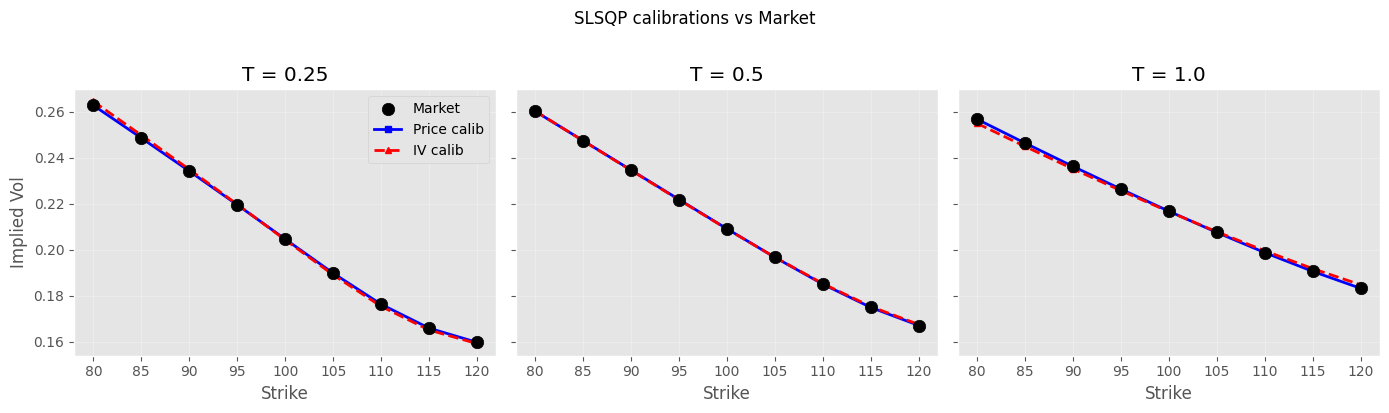

In [8]:
# model IVs for both SLSQP calibrations
IV_price_cos = [implied_vol(Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *params_price_cos), 
                            S0, K_mkt[i], r, T_mkt[i]) for i in range(n_instruments)]
IV_iv_cos = [implied_vol(Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *params_iv_cos), 
                         S0, K_mkt[i], r, T_mkt[i]) for i in range(n_instruments)]

n_K = len(K_strikes)
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for j, T in enumerate(T_maturities):
    idx = slice(j*n_K, (j+1)*n_K)
    
    axs[j].scatter(K_strikes, IV_mkt[idx], s=80, c='black', marker='o', 
                   label='Market', zorder=3)
    axs[j].plot(K_strikes, IV_price_cos[idx], 'b-', lw=2, marker='s', 
                markersize=5, label='Price calib')
    axs[j].plot(K_strikes, IV_iv_cos[idx], 'r--', lw=2, marker='^', 
                markersize=5, label='IV calib')
    
    axs[j].set_xlabel('Strike')
    axs[j].set_title(f'T = {T}')
    axs[j].grid(True, alpha=0.3)

axs[0].set_ylabel('Implied Vol')
axs[0].legend(loc='upper right')
plt.suptitle('SLSQP calibrations vs Market', y=1.02)
plt.tight_layout()
plt.show()

## Python Levenberg-Marquardt

SLSQP treats the MSE as a scalar — it can't see the structure of individual residuals. `least_squares` with `method='trf'` (trust-region reflective, LM variant with bounds support) exploits the least-squares structure and uses the Jacobian of the residual vector. Same Python, same COS pricer — only the algorithm changes.

In [9]:
params0 = [2.0, 0.25**2, 0.25**2, 0.5, -0.8]

# price residuals
t0 = time.time()
result_lm_price = least_squares(residuals_price_COS, params0,
                                bounds=(bounds_lower, bounds_upper), method='trf')
time_lm_price = time.time() - t0
params_lm_price = result_lm_price.x

print(f"Python LM Price-MSE ({time_lm_price:.2f}s, {result_lm_price.nfev} func evals)\n")
print_calib_result(params_lm_price, "LM Price")

# IV residuals
t0 = time.time()
result_lm_iv = least_squares(residuals_iv_COS, params0,
                             bounds=(bounds_lower, bounds_upper), method='trf')
time_lm_iv = time.time() - t0
params_lm_iv = result_lm_iv.x

print(f"\nPython LM IV-MSE ({time_lm_iv:.2f}s, {result_lm_iv.nfev} func evals)\n")
print_calib_result(params_lm_iv, "LM IV")

Python LM Price-MSE (0.14s, 11 func evals)

   Param   Calibrated         True    Rel Error
------------------------------------------------
   kappa     1.500000       1.5000       0.00%
     nu0     0.040000       0.0400       0.00%
   theta     0.060000       0.0600       0.00%
      xi     0.400000       0.4000       0.00%
     rho    -0.700000      -0.7000       0.00%

Feller: 2*kappa*theta - xi^2 = 0.0200 > 0

Python LM IV-MSE (0.50s, 7 func evals)

   Param   Calibrated         True    Rel Error
------------------------------------------------
   kappa     1.500000       1.5000       0.00%
     nu0     0.040000       0.0400       0.00%
   theta     0.060000       0.0600       0.00%
      xi     0.400000       0.4000       0.00%
     rho    -0.700000      -0.7000       0.00%

Feller: 2*kappa*theta - xi^2 = 0.0200 > 0


## Multi-start and global optimization

Single starting point on a flat loss surface is unreliable. `differential_evolution` searches globally — no starting point needed. We also run a multi-start SLSQP for comparison.

In [10]:
# differential evolution — global optimizer, no starting point bias
de_bounds = list(zip(bounds_lower, bounds_upper))

t0 = time.time()
result_de = differential_evolution(MSE_IV_COS, de_bounds, seed=42, tol=1e-10,
                                   maxiter=200, polish=True)
time_de = time.time() - t0
params_de = result_de.x

print(f"Differential Evolution IV-MSE ({time_de:.1f}s)\n")
print_calib_result(params_de, "DE", result_de)

# multi-start SLSQP: 20 random starting points, keep best
np.random.seed(42)
best_mse = np.inf
best_params = None
n_starts = 20

t0 = time.time()
for _ in range(n_starts):
    p0 = [np.random.uniform(lo, hi) for lo, hi in de_bounds]
    try:
        res = minimize(MSE_IV_COS, p0, constraints=cons, method='SLSQP',
                       bounds=de_bounds, tol=1e-10)
        if res.fun < best_mse:
            best_mse = res.fun
            best_params = res.x.copy()
    except:
        continue
time_ms = time.time() - t0

print(f"\nMulti-start SLSQP ({n_starts} starts, {time_ms:.1f}s)\n")
print_calib_result(best_params, "Multi-start SLSQP")

Differential Evolution IV-MSE (162.5s)

   Param   Calibrated         True    Rel Error
------------------------------------------------
   kappa     1.500000       1.5000       0.00%
     nu0     0.040000       0.0400       0.00%
   theta     0.060000       0.0600       0.00%
      xi     0.400000       0.4000       0.00%
     rho    -0.700000      -0.7000       0.00%

Feller: 2*kappa*theta - xi^2 = 0.0200 > 0
Converged: False, Iterations: 200, Final MSE: 3.54e-19

Multi-start SLSQP (20 starts, 45.8s)

   Param   Calibrated         True    Rel Error
------------------------------------------------
   kappa     1.500403       1.5000       0.03%
     nu0     0.040000       0.0400       0.00%
   theta     0.059995       0.0600       0.01%
      xi     0.400007       0.4000       0.00%
     rho    -0.700013      -0.7000       0.00%

Feller: 2*kappa*theta - xi^2 = 0.0200 > 0


In [11]:
# C++ Levenberg-Marquardt
# generate reference IVs from C++ pricer — same method for generation and calibration
import cppfm

T_unique = T_maturities
K_unique = K_strikes
n_K = len(K_unique)

IV_mkt_cpp = []
for i in range(n_instruments):
    price_cpp = cppfm.heston_call_price(S0, K_mkt[i], r, T_mkt[i],
                                         true_kappa, true_theta, true_xi, true_rho, true_nu0)
    IV_mkt_cpp.append(cppfm.bs_implied_volatility(S0, K_mkt[i], r, T_mkt[i], price_cpp,
                                                    cppfm.OptionType.Call))

slices = []
for T in T_unique:
    s = cppfm.HestonSliceData()
    s.T = T
    mask = [i for i in range(n_instruments) if T_mkt[i] == T]
    s.strikes = [K_mkt[i] for i in mask]
    s.market_ivs = [IV_mkt_cpp[i] for i in mask]
    slices.append(s)

guess = cppfm.HestonParams(v0=0.25**2, kappa=2.0, vbar=0.25**2, sigma_v=0.5, rho=-0.8)

t0 = time.time()
result_cpp = cppfm.calibrate_heston(slices, S0=S0, r=r, guess=guess)
time_cpp = time.time() - t0

p = result_cpp.params
params_cpp = [p.kappa, p.v0, p.vbar, p.sigma_v, p.rho]
print(f"C++ LM: {result_cpp.iterations} iters, RMSE={result_cpp.rmse:.2e}, {time_cpp:.4f}s")
print(f"Converged: {result_cpp.converged}\n")
print_calib_result(params_cpp, "C++ LM")

C++ LM: 6 iters, RMSE=4.26e-09, 0.0153s
Converged: True

   Param   Calibrated         True    Rel Error
------------------------------------------------
   kappa     1.500000       1.5000       0.00%
     nu0     0.040000       0.0400       0.00%
   theta     0.060000       0.0600       0.00%
      xi     0.400000       0.4000       0.00%
     rho    -0.700000      -0.7000       0.00%

Feller: 2*kappa*theta - xi^2 = 0.0200 > 0


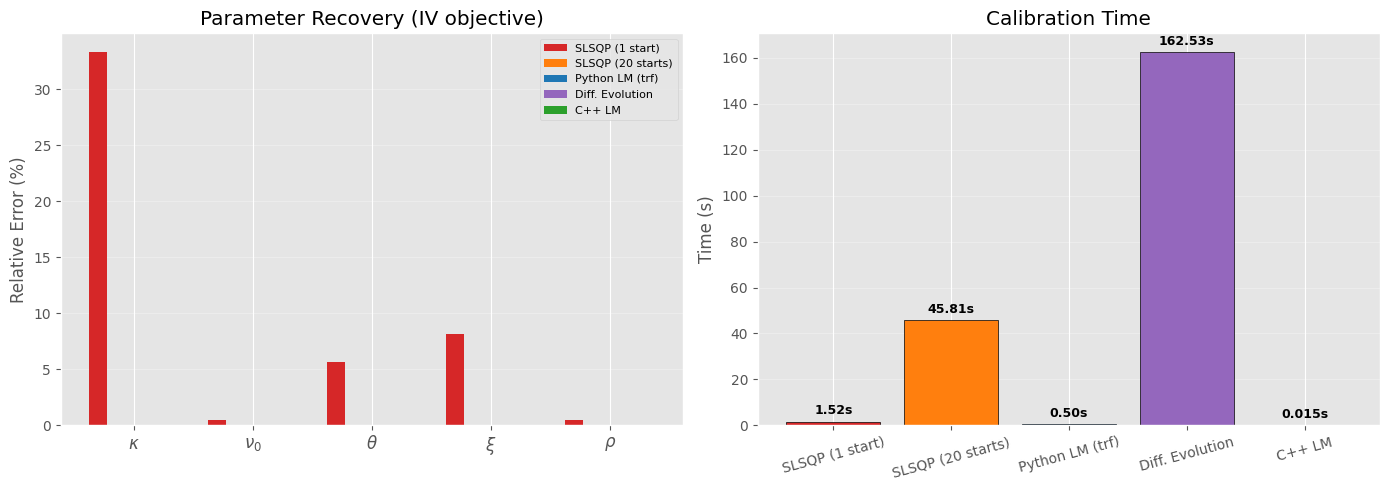

In [12]:
# all-methods comparison
all_methods = {
    'SLSQP (1 start)': (params_iv_cos, time_iv_cos),
    'SLSQP (20 starts)': (best_params, time_ms),
    'Python LM (trf)': (params_lm_iv, time_lm_iv),
    'Diff. Evolution': (params_de, time_de),
    'C++ LM': (params_cpp, time_cpp),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(5)
width = 0.15
colors = ['#d62728', '#ff7f0e', '#1f77b4', '#9467bd', '#2ca02c']

for j, (method, (params, _)) in enumerate(all_methods.items()):
    errors = [abs(params[i] - true_params[i]) / abs(true_params[i]) * 100 for i in range(5)]
    ax1.bar(x + (j - 2)*width, errors, width, label=method, color=colors[j])

ax1.set_xticks(x)
ax1.set_xticklabels([r'$\kappa$', r'$\nu_0$', r'$\theta$', r'$\xi$', r'$\rho$'], fontsize=12)
ax1.set_ylabel('Relative Error (%)')
ax1.set_title('Parameter Recovery (IV objective)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')

# timing
method_names = list(all_methods.keys())
times_list = [t for _, t in all_methods.values()]
bars = ax2.bar(method_names, times_list, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Time (s)')
ax2.set_title('Calibration Time')
for bar, t in zip(bars, times_list):
    label = f'{t:.2f}s' if t >= 0.1 else f'{t:.3f}s'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times_list)*0.02,
             label, ha='center', fontsize=9, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

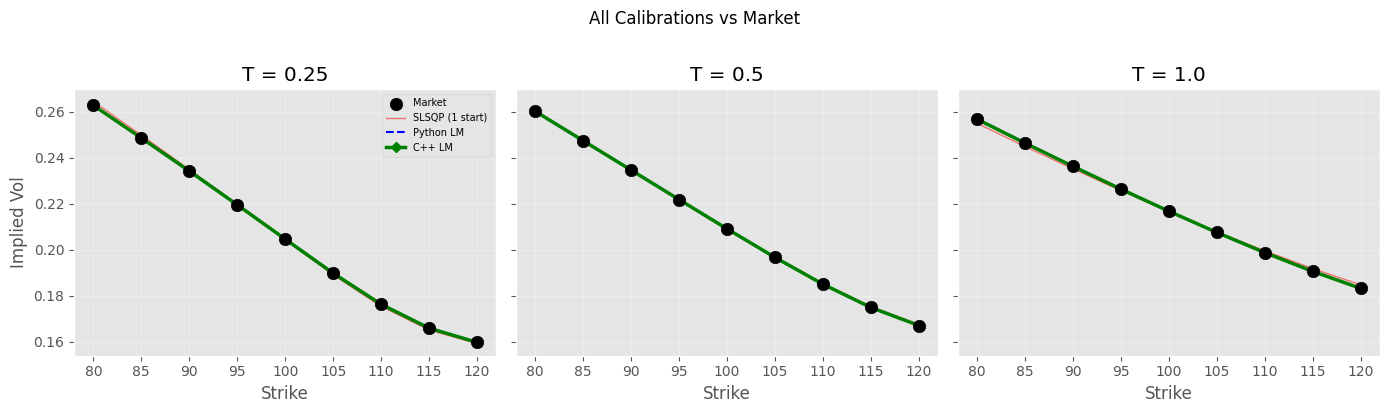

In [13]:
# IVs from all methods
def compute_ivs(params_calib):
    return [implied_vol(Heston_price_COS(S0, K_mkt[i], T_mkt[i], r, *params_calib),
                        S0, K_mkt[i], r, T_mkt[i]) for i in range(n_instruments)]

IV_lm = compute_ivs(params_lm_iv)
IV_de = compute_ivs(params_de)

# C++ IVs via cppfm pricing
IV_cpp = []
for i in range(n_instruments):
    price = cppfm.heston_call_price(S0, K_mkt[i], r, T_mkt[i],
                                     p.kappa, p.vbar, p.sigma_v, p.rho, p.v0)
    IV_cpp.append(implied_vol(price, S0, K_mkt[i], r, T_mkt[i]))

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for j, T in enumerate(T_unique):
    idx = slice(j*n_K, (j+1)*n_K)

    axs[j].scatter(K_unique, IV_mkt[idx], s=80, c='black', marker='o',
                   label='Market', zorder=3)
    axs[j].plot(K_unique, IV_iv_cos[idx], 'r-', lw=1, alpha=0.5, label='SLSQP (1 start)')
    axs[j].plot(K_unique, IV_lm[idx], 'b--', lw=1.5, label='Python LM')
    axs[j].plot(K_unique, IV_cpp[idx], 'g-', lw=2.5, marker='D',
                markersize=5, label='C++ LM')

    axs[j].set_xlabel('Strike')
    axs[j].set_title(f'T = {T}')
    axs[j].grid(True, alpha=0.3)

axs[0].set_ylabel('Implied Vol')
axs[0].legend(loc='upper right', fontsize=7)
plt.suptitle('All Calibrations vs Market', y=1.02)
plt.tight_layout()
plt.show()

## Hessian analysis: why kappa is hard to pin down

Assertions about "flat loss surface" need proof. The Hessian of the objective at the optimum tells us which parameter directions are well-constrained (large eigenvalues) and which are sloppy (small eigenvalues). The eigenvector associated with the smallest eigenvalue points along the valley floor.

Hessian eigenspectrum at optimum:
    Eigenvalue   Condition  Direction (kappa, nu0, theta, xi, rho)
--------------------------------------------------------------------------------
      6.59e-06    893153.3x  [kappa:+0.998  nu0:-0.000  theta:-0.009  xi:+0.063  rho:+0.005]
      6.07e-04      9696.0x  [kappa:-0.041  nu0:-0.009  theta:+0.027  xi:+0.592  rho:+0.804]
      1.07e-02       549.2x  [kappa:+0.047  nu0:+0.002  theta:-0.050  xi:-0.801  rho:+0.594]
      3.20e-01        18.4x  [kappa:-0.012  nu0:+0.402  theta:-0.914  xi:+0.054  rho:-0.005]
      5.89e+00         1.0x  [kappa:+0.005  nu0:+0.916  theta:+0.401  xi:-0.016  rho:+0.009]

Condition number: 893153

Flattest direction dominated by: kappa (+0.998)  xi (+0.063)  theta (-0.009)  

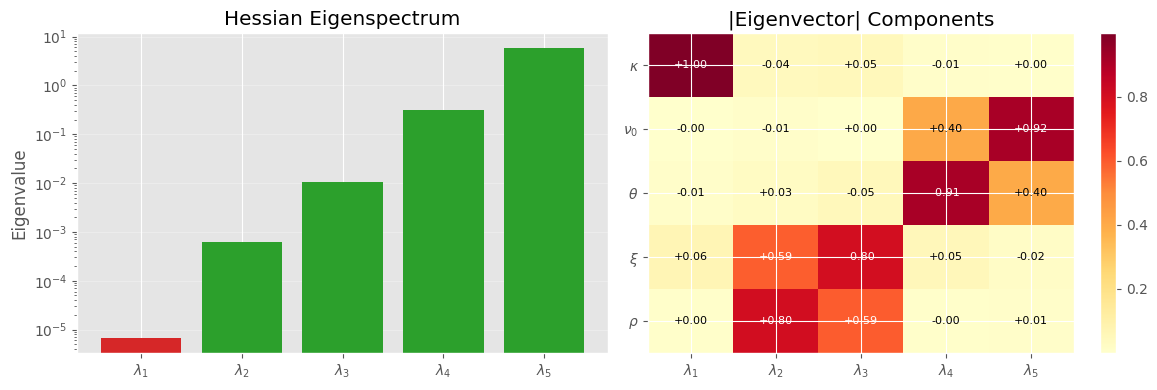

In [14]:
# Hessian via finite differences at the best Python result
from scipy.optimize import approx_fprime

def hessian_fd(f, x, eps=1e-5):
    """Hessian via central finite differences."""
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        def gi(xi_val):
            x_copy = x.copy()
            x_copy[i] = xi_val
            return approx_fprime(x_copy, f, eps)
        g_plus = gi(x[i] + eps)
        g_minus = gi(x[i] - eps)
        H[i] = (g_plus - g_minus) / (2 * eps)
    # symmetrize
    return 0.5 * (H + H.T)

# use the best result we have (DE or LM)
params_best = params_de
H = hessian_fd(MSE_IV_COS, params_best)

eigvals, eigvecs = np.linalg.eigh(H)

print("Hessian eigenspectrum at optimum:")
print(f"{'Eigenvalue':>14}  {'Condition':>10}  Direction (kappa, nu0, theta, xi, rho)")
print("-" * 80)
for i in range(5):
    v = eigvecs[:, i]
    cond = eigvals[-1] / max(eigvals[i], 1e-20)
    # normalize for readability
    v_str = "  ".join([f"{param_names[j]}:{v[j]:+.3f}" for j in range(5)])
    print(f"{eigvals[i]:>14.2e}  {cond:>10.1f}x  [{v_str}]")

print(f"\nCondition number: {eigvals[-1] / max(eigvals[0], 1e-20):.0f}")

# which parameters dominate the flattest direction?
flat_dir = eigvecs[:, 0]
print(f"\nFlattest direction dominated by: ", end="")
sorted_idx = np.argsort(np.abs(flat_dir))[::-1]
for idx in sorted_idx[:3]:
    print(f"{param_names[idx]} ({flat_dir[idx]:+.3f})  ", end="")

# visualize: eigenvalue spectrum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(5), eigvals, color=['#d62728' if e == eigvals[0] else '#2ca02c' for e in eigvals])
ax1.set_xticks(range(5))
ax1.set_xticklabels([f'$\\lambda_{i+1}$' for i in range(5)])
ax1.set_ylabel('Eigenvalue')
ax1.set_title('Hessian Eigenspectrum')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, axis='y')

# eigenvector heatmap
im = ax2.imshow(np.abs(eigvecs), cmap='YlOrRd', aspect='auto')
ax2.set_xticks(range(5))
ax2.set_xticklabels([f'$\\lambda_{i+1}$' for i in range(5)])
ax2.set_yticks(range(5))
ax2.set_yticklabels([r'$\kappa$', r'$\nu_0$', r'$\theta$', r'$\xi$', r'$\rho$'])
ax2.set_title('|Eigenvector| Components')
plt.colorbar(im, ax=ax2)

# annotate values
for i in range(5):
    for j in range(5):
        ax2.text(j, i, f'{eigvecs[i,j]:+.2f}', ha='center', va='center', fontsize=8,
                 color='white' if abs(eigvecs[i,j]) > 0.5 else 'black')

plt.tight_layout()
plt.show()

Interpretation:
- Hessian is the curvature matrix of the loss function at the optimum. Its eigenvalues tell us how steep/flat the loss surface is in each direction:
    - Large eigenvalue = steep valley -> parameter is well-identified. Moving away a tiny-bit costs a lot.
    - Small eigenvalue = nearly flat region -> parameter is poorly identified. E.g. changing kappa by a lot barely moves the loss - so the optimizer just "slides along the floor"
    - Condition number = ratio of steepest to flattest. 

The heatmap: 
- To see this, imagine the loss surface as a 5D bowl, not symmetric one. Each eigenvector represents a direction in the parameter space.
- Each column is an eigen-direction, each row is a parameter.
- Darker the color the parameter contributes more in that direction.
    - i.e. when the optimizer moves along that eigen-direction, that parameter is the one changing. A parameter that's dark in a flat column (small eigenvalue) is one the data cannot control well.
